In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')

os.makedirs('plots', exist_ok=True)
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
df = pd.read_csv('../data/dataCleaned.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPrice stats:")
print(df['price'].describe())
df.head()

Shape: (96125, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize', 'brand']

Price stats:
count    96125.000000
mean     16567.395984
std       9472.798476
min       1000.000000
25%       9998.000000
50%      14200.000000
75%      20490.000000
max      99950.000000
Name: price, dtype: float64


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


Category distribution:
  Budget (0): 24,981 cars (26.0%)
  Mid-Range (1): 46,472 cars (48.3%)
  Premium (2): 24,672 cars (25.7%)


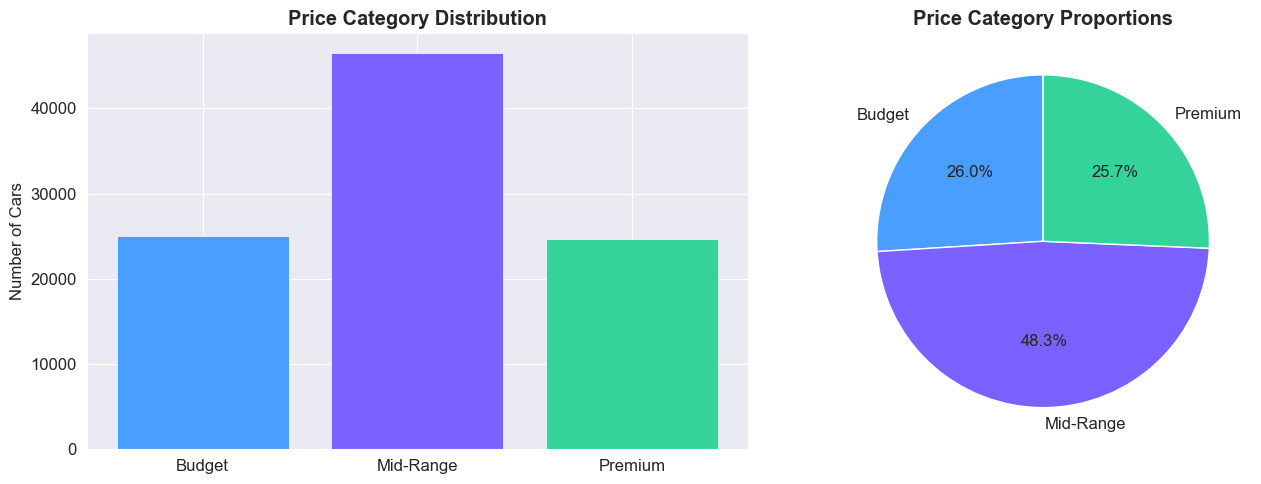

Target variable created!


In [12]:
bins   = [0, 10000, 20000, 100000]
labels = [0, 1, 2]
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels).astype(int)

label_names = {0: 'Budget', 1: 'Mid-Range', 2: 'Premium'}

print("Category distribution:")
counts = df['price_category'].value_counts().sort_index()
for cat, count in counts.items():
    print(f"  {label_names[cat]} ({cat}): {count:,} cars ({count/len(df)*100:.1f}%)")

colors = ['#4a9eff', '#7b61ff', '#34d399']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([label_names[i] for i in sorted(counts.index)],
            [counts[i] for i in sorted(counts.index)],
            color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Price Category Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Cars')

axes[1].pie([counts[i] for i in sorted(counts.index)],
            labels=[label_names[i] for i in sorted(counts.index)],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Price Category Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Target variable created!")